In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator, interp1d
import pickle

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [4]:
t_Myr_sec = 3.1689E-14 # Conversion from seconds to Myr

# Functions for PIE temperature, cooling/recombination time

Load cooling times and temperatures saved for PIE (main grid run)

In [5]:
# Unique grids in density/metallicity
log_hdens_arr = np.arange(-5, 1.25, 0.25)
log_metals_arr = np.arange(-3, 1.25, 0.25)
N_pts = len(log_hdens_arr)*len(log_metals_arr)

log_hdens_sub_arr = np.arange(-4.25, 1.25, 0.25)
log_metals_sub_arr = np.arange(-0.25, 1.25, 0.25)

In [6]:
# Grid of cooling times, in seconds, need to convert to Myr
# Index only accesses for unique density/metallicities
t_cool_grid = np.loadtxt(rootdir+'cloudy_grids/t_cool.txt', delimiter=',')[2::3]*t_Myr_sec
t_cool_grid = t_cool_grid.reshape(len(log_hdens_arr),len(log_metals_arr))

# Store these into a dictionary
logt_cool_dict = {}

# Measurements after adding blackbody heating

for i in range(len(log_hdens_arr)):
    for j in range(len(log_metals_arr)):
        log_hdens = log_hdens_arr[i]
        log_metals = log_metals_arr[j]
        logt_cool_dict[(log_hdens,log_metals)] = np.log10(t_cool_grid[i,j])

t_cool_sub_grid = np.loadtxt(rootdir+'cloudy_grids/t_cool_sub.txt', delimiter=',')[2::3]*t_Myr_sec
t_cool_sub_grid = t_cool_sub_grid.reshape(len(log_hdens_sub_arr),len(log_metals_sub_arr))

logt_cool_sub_dict = {}

for i in range(len(log_hdens_sub_arr)):
    for j in range(len(log_metals_sub_arr)):
        log_hdens = log_hdens_sub_arr[i]
        log_metals = log_metals_sub_arr[j]
        logt_cool_sub_dict[(log_hdens,log_metals)] = np.log10(t_cool_sub_grid[i,j])

In [7]:
# Load in final temperatures and reshape
logT_grid = np.loadtxt(rootdir+'cloudy_grids/final_flat_logT.dat')[:N_pts]
logT_grid = logT_grid.reshape(len(log_hdens_arr),len(log_metals_arr))

In [8]:
logt_cool_grid = np.zeros(t_cool_grid.shape)

for i in range(len(log_hdens_arr)):
    for j in range(len(log_metals_arr)):
        log_hdens = log_hdens_arr[i]
        log_metals = log_metals_arr[j]
        if logT_grid[i,j] == 4.: # Needed to add blackbody heating
            logt_cool_grid[i,j] = logt_cool_sub_dict[(log_hdens,log_metals)]
        else:
            logt_cool_grid[i,j] = logt_cool_dict[(log_hdens,log_metals)]

Interpolate temperatures and cooling times

In [9]:
logT_interp = RegularGridInterpolator((log_hdens_arr, log_metals_arr), logT_grid)
logt_cool_interp = RegularGridInterpolator((log_hdens_arr, log_metals_arr), logt_cool_grid)

Interpolate recombination times

In [10]:
# From CLOUDY calculations
logT_rec_grid = np.array([4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4,
        6.6, 6.8, 7. , 7.2, 7.4, 7.6, 7.8, 8. ])

logq_rec_grid = np.log10(np.array([5.14e-12, 3.75e-12, 2.72e-12, 1.96e-12, 1.40e-12, 9.95e-13,
        6.99e-13, 4.86e-13, 3.34e-13, 2.26e-13, 1.50e-13, 9.80e-14,
        6.27e-14, 3.93e-14, 2.41e-14, 1.44e-14, 8.47e-15, 4.86e-15,
        2.74e-15, 1.52e-15, 1.52e-15]))

In [11]:
logq_rec_interp = interp1d(logT_rec_grid, logq_rec_grid, fill_value='extrapolate')

In [12]:
def logt_rec(log_hdens, logT, logq_rec_interp):
    
    logq = logq_rec_interp(logT)
    logt_rec = np.log10((10**log_hdens*10**logq)**-1*t_Myr_sec)
    
    return logt_rec

Functions to get distributions of $T$, $t_\mathrm{rec}$ and $t_\mathrm{cool}/t_\mathrm{rec}$

In [13]:
def get_cooling_dist(log_hdens_samples, log_metals_samples, logq_rec_interp, logt_cool_interp):
    
    # Distribution of PIE temperatures
    logT_samples = logT_interp((log_hdens_samples, log_metals_samples))
    
    # Distribution of recombination times
    logt_rec_samples = logt_rec(log_hdens_samples, logT_samples, logq_rec_interp)
    
    # Distribution of cooling times
    logt_cool_samples = logt_cool_interp((log_hdens_samples, log_metals_samples))
    
    return np.array(logT_samples), np.array(logt_rec_samples), np.array(logt_cool_samples)

In [14]:
loaddir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/'

Diagnostic plots

In [15]:
log_hdens_test_arr = np.arange(-4.6, -2.3, 0.05)

Text(0, 0.5, '$\\log(T/\\mathrm{K})$')

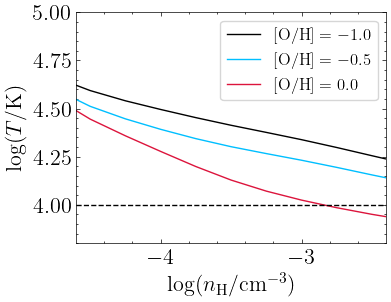

In [16]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,-1.0)), label=r'$[\mathrm{O/H}]=-1.0$')
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,-0.5)), label=r'$[\mathrm{O/H}]=-0.5$')
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,0.0)), label=r'$[\mathrm{O/H}]=0.0$')

ax.axhline(4.0,linestyle='--')
ax.set_xlim(-4.6,-2.4)
ax.set_ylim(3.8,5.0)

ax.legend()

ax.set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
ax.set_ylabel(r'$\log(T/\mathrm{K})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

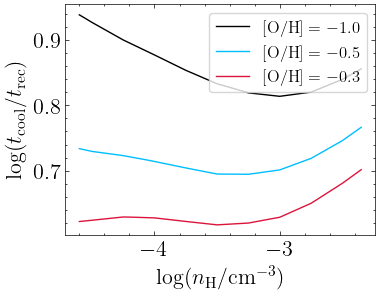

In [17]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-1.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-1.0$')

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-0.5))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-0.5)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-0.5$')

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-0.3))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-0.3)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-0.3$')

ax.legend()
ax.set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

In [18]:
log_metals_test_arr = np.arange(-3.0, 1., 0.1)

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

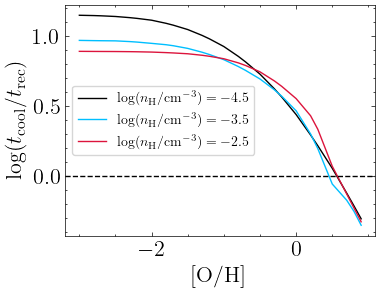

In [19]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_metals_test_arr,
        logt_cool_interp((-4.5,log_metals_test_arr))-logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-3.5,log_metals_test_arr))-logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-2.5,log_metals_test_arr))-logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$')

ax.axhline(0, linestyle='--')

ax.legend(fontsize=10)
ax.set_xlabel(r'$\mathrm{[O/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

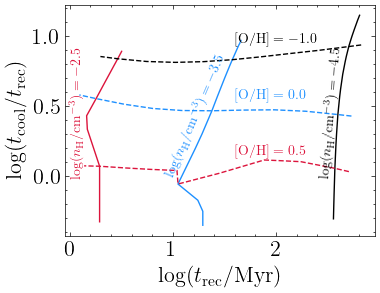

In [20]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-4.5,log_metals_test_arr))-logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$',color='black')

ax.text(2.4,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$',fontsize=10, rotation=85, color='black')

ax.plot(logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-3.5,log_metals_test_arr))-logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$',color='dodgerblue')

ax.text(0.9,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$',fontsize=10, rotation=67, color='dodgerblue')

ax.plot(logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-2.5,log_metals_test_arr))-logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$',color='crimson')

ax.text(0.0,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$',fontsize=10, rotation=90, color='crimson')

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,-1.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-1.0$',color='black', linestyle='--')

ax.text(1.6,0.95,r'$\mathrm{[O/H]}=-1.0$',fontsize=10)

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.0)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,0.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=0.0$',color='dodgerblue', linestyle='--')

ax.text(1.6,0.55,r'$\mathrm{[O/H]}=0.0$',fontsize=10,color='dodgerblue')

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.5)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,0.5))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.5)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=0.5$',color='crimson', linestyle='--')

ax.text(1.6,0.15,r'$\mathrm{[O/H]}=0.5$',fontsize=10,color='crimson')

ax.set_xlabel(r'$\log(t_\mathrm{rec}/\mathrm{Myr})$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

# z=0.67, PIE

## c1

In [21]:
z_067_c1_PIE_samples = pd.read_csv(loaddir+'z=0.67545705/cloudy_fits/two_phase_CN.csv')

### c1H

In [22]:
z_067_c1L_PIE_logT, z_067_c1L_PIE_logt_rec, z_067_c1L_PIE_logt_cool = get_cooling_dist(z_067_c1_PIE_samples['log_hdens_p1'],
                                                                                             z_067_c1_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   77.,   472.,  2502.,  6092.,  8514., 15945., 33716., 12344.,
          219.,   119.]),
 array([4.08360705, 4.11955354, 4.15550003, 4.19144652, 4.22739301,
        4.2633395 , 4.299286  , 4.33523249, 4.37117898, 4.40712547,
        4.44307196]),
 <BarContainer object of 10 artists>)

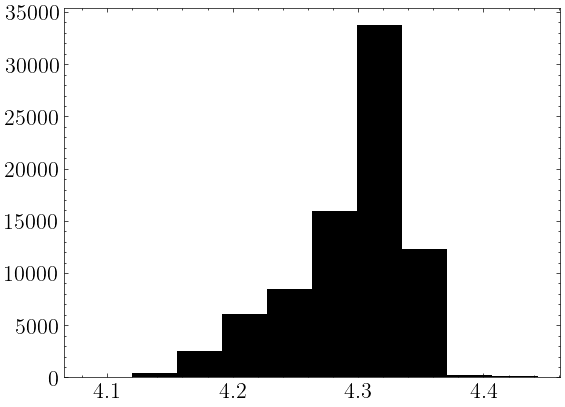

In [23]:
plt.hist(z_067_c1L_PIE_logT)

In [24]:
get_quantiles(z_067_c1L_PIE_logT)

4.31 -0.07 0.03


(array([1.0000e+00, 2.1000e+01, 2.4500e+02, 2.0790e+03, 6.5450e+03,
        9.4740e+03, 1.3429e+04, 1.9713e+04, 2.4830e+04, 3.6630e+03]),
 array([-0.3217125 , -0.14487338,  0.03196575,  0.20880488,  0.38564401,
         0.56248314,  0.73932226,  0.91616139,  1.09300052,  1.26983965,
         1.44667878]),
 <BarContainer object of 10 artists>)

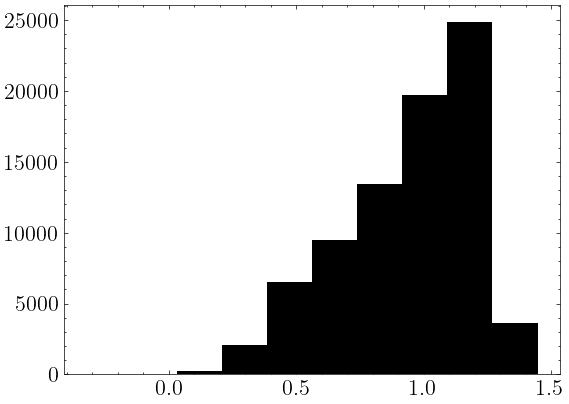

In [25]:
plt.hist(z_067_c1L_PIE_logt_rec)

In [26]:
get_quantiles(z_067_c1L_PIE_logt_rec)

1.01 -0.37 0.18


(array([7.0000e+00, 1.2100e+02, 4.1590e+03, 4.7765e+04, 2.1751e+04,
        4.3830e+03, 1.1050e+03, 3.8300e+02, 2.5800e+02, 6.8000e+01]),
 array([0.70817085, 0.72759096, 0.74701108, 0.7664312 , 0.78585131,
        0.80527143, 0.82469154, 0.84411166, 0.86353177, 0.88295189,
        0.90237201]),
 <BarContainer object of 10 artists>)

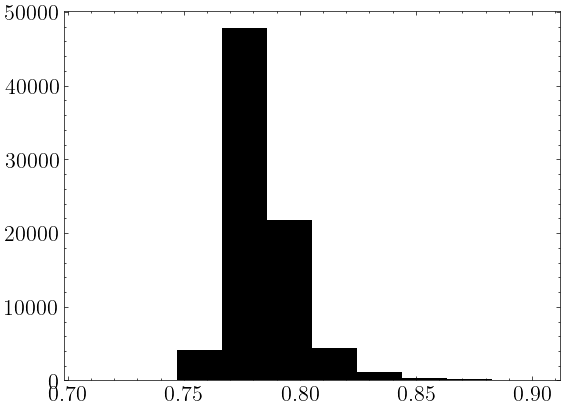

In [27]:
plt.hist(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec)

In [28]:
get_quantiles(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec)

0.78 -0.01 0.01


### c1H

In [29]:
z_067_c1H_PIE_logT, z_067_c1H_PIE_logt_rec, z_067_c1H_PIE_logt_cool = get_cooling_dist(z_067_c1_PIE_samples['log_hdens_p2'],
                                                                                             z_067_c1_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   36.,    90.,   644.,  1167.,  3879., 10134., 18808., 24234.,
        17226.,  3782.]),
 array([3.84158061, 3.91227575, 3.9829709 , 4.05366604, 4.12436118,
        4.19505632, 4.26575146, 4.33644661, 4.40714175, 4.47783689,
        4.54853203]),
 <BarContainer object of 10 artists>)

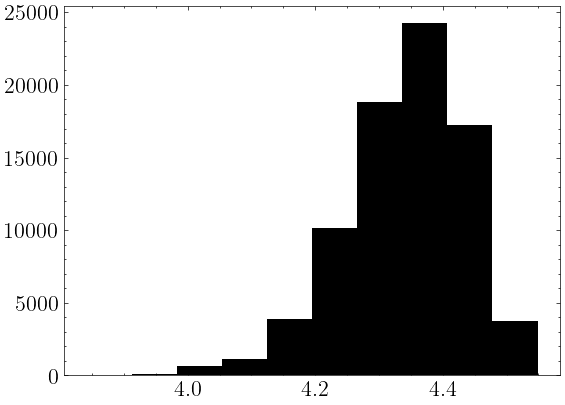

In [30]:
plt.hist(z_067_c1H_PIE_logT)

In [31]:
get_quantiles(z_067_c1H_PIE_logT)

4.35 -0.1 0.08


(array([  366.,  5509., 19667., 27113., 18089.,  7286.,  1402.,   400.,
          114.,    54.]),
 array([1.46985662, 1.59704988, 1.72424314, 1.85143641, 1.97862967,
        2.10582293, 2.23301619, 2.36020946, 2.48740272, 2.61459598,
        2.74178924]),
 <BarContainer object of 10 artists>)

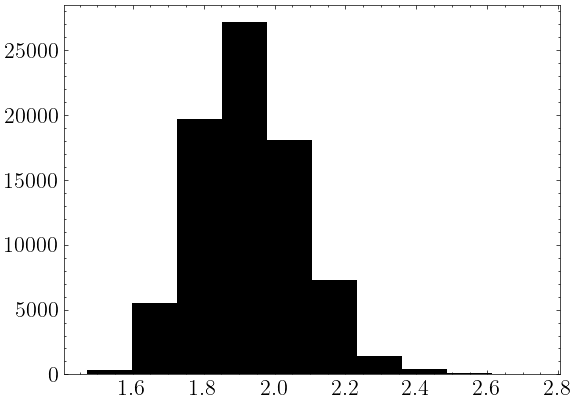

In [32]:
plt.hist(z_067_c1H_PIE_logt_rec)

In [33]:
get_quantiles(z_067_c1H_PIE_logt_rec)

1.92 -0.14 0.16


(array([3.8000e+01, 2.4000e+01, 1.6200e+02, 3.1700e+02, 6.9400e+02,
        2.5370e+03, 8.0730e+03, 1.9488e+04, 3.1443e+04, 1.7224e+04]),
 array([-0.46332153, -0.32619691, -0.18907229, -0.05194767,  0.08517694,
         0.22230156,  0.35942618,  0.49655079,  0.63367541,  0.77080003,
         0.90792465]),
 <BarContainer object of 10 artists>)

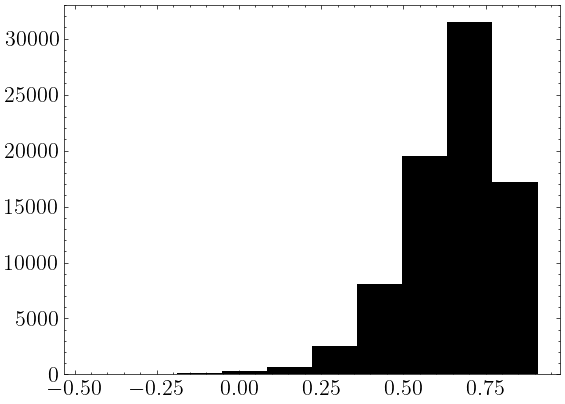

In [34]:
plt.hist(z_067_c1H_PIE_logt_cool-z_067_c1H_PIE_logt_rec)

In [35]:
get_quantiles(z_067_c1H_PIE_logt_cool-z_067_c1H_PIE_logt_rec)

0.67 -0.17 0.12


# z=1.04, PIE

## c1

In [52]:
z_104_c1_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/one_phase_c1.csv')

In [53]:
z_104_c1_PIE_logT, z_104_c1_PIE_logt_rec, z_104_c1_PIE_logt_cool = get_cooling_dist(z_104_c1_PIE_samples['log_hdens'],
                                                                                    z_104_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   37.,   243.,   845.,  2494.,  7720., 20376., 27393., 17290.,
         3532.,    70.]),
 array([3.84210361, 3.88614502, 3.93018644, 3.97422785, 4.01826927,
        4.06231069, 4.1063521 , 4.15039352, 4.19443493, 4.23847635,
        4.28251776]),
 <BarContainer object of 10 artists>)

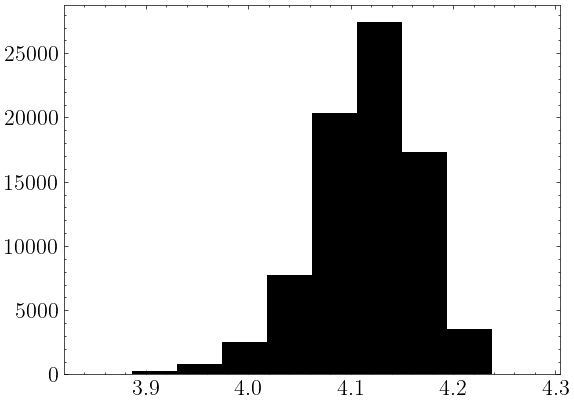

In [54]:
plt.hist(z_104_c1_PIE_logT)

In [55]:
get_quantiles(z_104_c1_PIE_logT)

4.12 -0.05 0.05


(array([  116.,   715.,  4539., 13576., 23106., 22107., 11764.,  3478.,
          565.,    34.]),
 array([0.6810346 , 0.75423142, 0.82742824, 0.90062506, 0.97382188,
        1.0470187 , 1.12021552, 1.19341234, 1.26660917, 1.33980599,
        1.41300281]),
 <BarContainer object of 10 artists>)

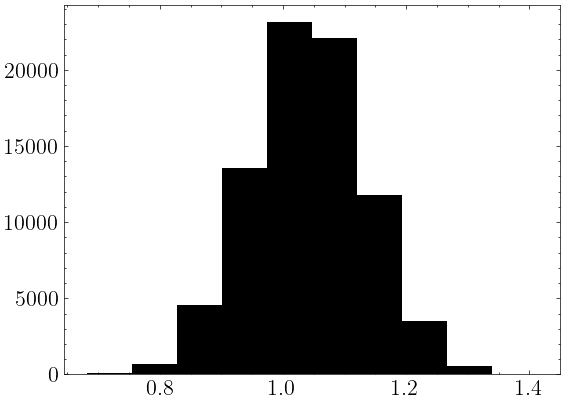

In [56]:
plt.hist(z_104_c1_PIE_logt_rec)

In [57]:
get_quantiles(z_104_c1_PIE_logt_rec)

1.04 -0.09 0.09


(array([   38.,   210.,   803.,  2163.,  6350., 19246., 27662., 18493.,
         4908.,   127.]),
 array([0.28922292, 0.32888986, 0.36855679, 0.40822373, 0.44789066,
        0.4875576 , 0.52722453, 0.56689147, 0.6065584 , 0.64622534,
        0.68589227]),
 <BarContainer object of 10 artists>)

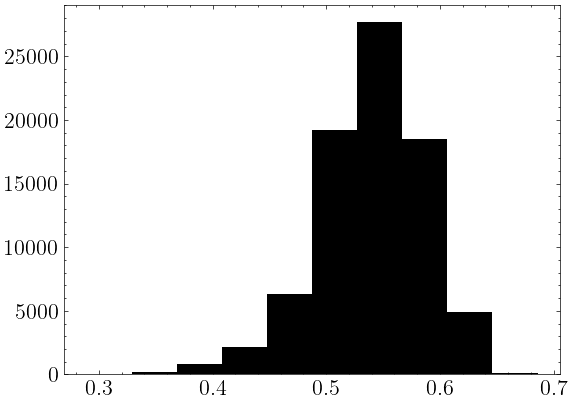

In [58]:
plt.hist(z_104_c1_PIE_logt_cool-z_104_c1_PIE_logt_rec)

In [59]:
get_quantiles(z_104_c1_PIE_logt_cool-z_104_c1_PIE_logt_rec)

0.54 -0.05 0.04


## c2

In [60]:
z_104_c2_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/one_phase_c2.csv')

In [61]:
z_104_c2_PIE_logT, z_104_c2_PIE_logt_rec, z_104_c2_PIE_logt_cool = get_cooling_dist(z_104_c2_PIE_samples['log_hdens'],
                                                                                    z_104_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([6.0000e+00, 9.0000e+00, 1.8900e+02, 1.5103e+04, 1.4671e+04,
        1.6994e+04, 1.6752e+04, 1.2887e+04, 3.2660e+03, 1.2300e+02]),
 array([3.70305784, 3.75905248, 3.81504713, 3.87104177, 3.92703641,
        3.98303105, 4.03902569, 4.09502034, 4.15101498, 4.20700962,
        4.26300426]),
 <BarContainer object of 10 artists>)

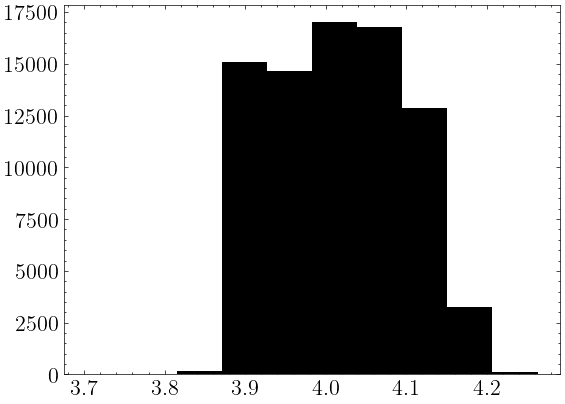

In [62]:
plt.hist(z_104_c2_PIE_logT)

In [63]:
get_quantiles(z_104_c2_PIE_logT)

4.02 -0.1 0.09


(array([2.0000e+01, 2.0400e+02, 2.7900e+03, 1.2122e+04, 2.0766e+04,
        2.3157e+04, 1.5006e+04, 5.0480e+03, 8.0900e+02, 7.8000e+01]),
 array([0.72928277, 0.81673369, 0.90418461, 0.99163553, 1.07908644,
        1.16653736, 1.25398828, 1.3414392 , 1.42889011, 1.51634103,
        1.60379195]),
 <BarContainer object of 10 artists>)

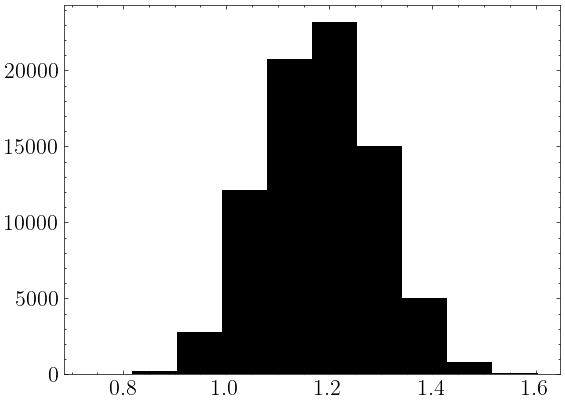

In [64]:
plt.hist(z_104_c2_PIE_logt_rec)

In [65]:
get_quantiles(z_104_c2_PIE_logt_rec)

1.18 -0.12 0.11


(array([   23.,   151.,  1504.,  5996., 11275., 16870., 19376., 17050.,
         7317.,   438.]),
 array([-0.02212008,  0.04131694,  0.10475395,  0.16819096,  0.23162798,
         0.29506499,  0.358502  ,  0.42193901,  0.48537603,  0.54881304,
         0.61225005]),
 <BarContainer object of 10 artists>)

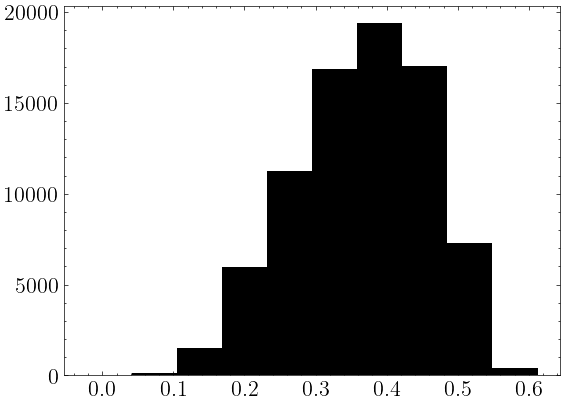

In [66]:
plt.hist(z_104_c2_PIE_logt_cool-z_104_c2_PIE_logt_rec)

In [67]:
get_quantiles(z_104_c2_PIE_logt_cool-z_104_c2_PIE_logt_rec)

0.37 -0.11 0.1


## c3

In [52]:
z_104_c3_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/one_phase_c3.csv')

In [53]:
z_104_c3_PIE_logT, z_104_c3_PIE_logt_rec, z_104_c3_PIE_logt_cool = get_cooling_dist(z_104_c3_PIE_samples['log_hdens'],
                                                                                    z_104_c3_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([5.0000e+00, 4.8000e+01, 2.8900e+02, 1.4170e+03, 5.8260e+03,
        1.7655e+04, 3.1038e+04, 1.9446e+04, 4.0590e+03, 2.1700e+02]),
 array([4.07191186, 4.09972908, 4.1275463 , 4.15536353, 4.18318075,
        4.21099797, 4.23881519, 4.26663242, 4.29444964, 4.32226686,
        4.35008408]),
 <BarContainer object of 10 artists>)

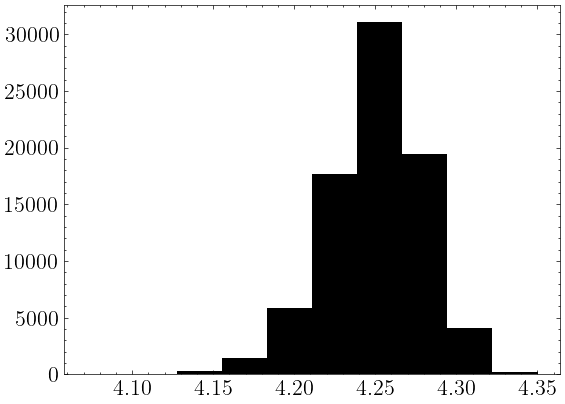

In [54]:
plt.hist(z_104_c3_PIE_logT)

In [55]:
get_quantiles(z_104_c3_PIE_logT)

4.25 -0.03 0.03


(array([1.7000e+01, 3.3400e+02, 2.8550e+03, 1.0783e+04, 2.4043e+04,
        2.5174e+04, 1.3046e+04, 3.4070e+03, 3.3100e+02, 1.0000e+01]),
 array([1.03948361, 1.12250093, 1.20551826, 1.28853558, 1.3715529 ,
        1.45457022, 1.53758755, 1.62060487, 1.70362219, 1.78663951,
        1.86965684]),
 <BarContainer object of 10 artists>)

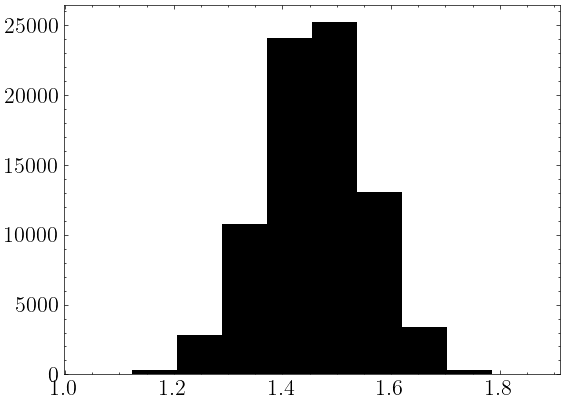

In [56]:
plt.hist(z_104_c3_PIE_logt_rec)

In [57]:
get_quantiles(z_104_c3_PIE_logt_rec)

1.46 -0.1 0.09


(array([8.0000e+00, 5.7000e+01, 3.7800e+02, 1.8440e+03, 6.7910e+03,
        2.3778e+04, 3.0993e+04, 1.3763e+04, 2.2810e+03, 1.0700e+02]),
 array([0.46775459, 0.49369961, 0.51964462, 0.54558964, 0.57153466,
        0.59747968, 0.62342469, 0.64936971, 0.67531473, 0.70125975,
        0.72720476]),
 <BarContainer object of 10 artists>)

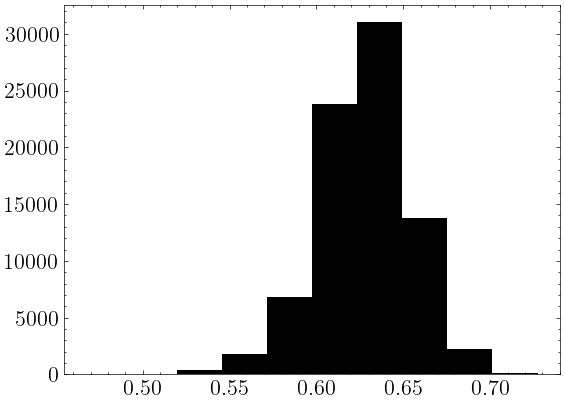

In [58]:
plt.hist(z_104_c3_PIE_logt_cool-z_104_c3_PIE_logt_rec)

In [59]:
get_quantiles(z_104_c3_PIE_logt_cool-z_104_c3_PIE_logt_rec)

0.63 -0.03 0.03


## c4

In [60]:
z_104_c4_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/one_phase_c4.csv')

In [61]:
z_104_c4_PIE_logT, z_104_c4_PIE_logt_rec, z_104_c4_PIE_logt_cool = get_cooling_dist(z_104_c4_PIE_samples['log_hdens'],
                                                                                    z_104_c4_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([1.8000e+01, 4.0000e+01, 1.4800e+02, 1.3600e+03, 6.3590e+03,
        1.8587e+04, 3.1293e+04, 1.8340e+04, 3.7170e+03, 1.3800e+02]),
 array([4.02078653, 4.06009616, 4.09940579, 4.13871542, 4.17802505,
        4.21733468, 4.25664431, 4.29595395, 4.33526358, 4.37457321,
        4.41388284]),
 <BarContainer object of 10 artists>)

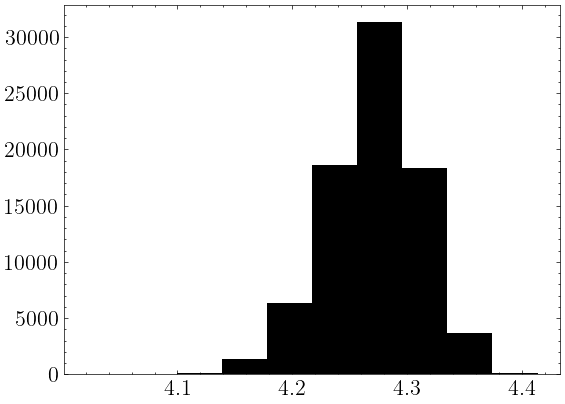

In [62]:
plt.hist(z_104_c4_PIE_logT)

In [63]:
get_quantiles(z_104_c4_PIE_logT)

4.27 -0.04 0.04


(array([1.8000e+01, 5.2100e+02, 3.5830e+03, 1.4104e+04, 2.5174e+04,
        2.2091e+04, 1.0190e+04, 3.2930e+03, 8.7800e+02, 1.4800e+02]),
 array([0.56200039, 0.68800724, 0.81401409, 0.94002094, 1.06602779,
        1.19203464, 1.31804148, 1.44404833, 1.57005518, 1.69606203,
        1.82206888]),
 <BarContainer object of 10 artists>)

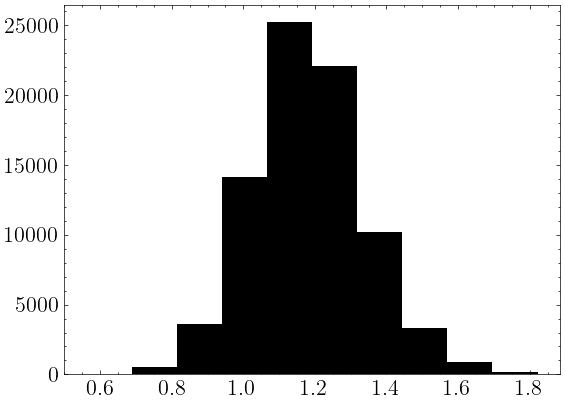

In [64]:
plt.hist(z_104_c4_PIE_logt_rec)

In [65]:
get_quantiles(z_104_c4_PIE_logt_rec)

1.18 -0.15 0.16


(array([8.0000e+00, 3.4000e+01, 2.1800e+02, 1.2930e+03, 6.2430e+03,
        1.6067e+04, 3.1544e+04, 1.9586e+04, 4.7540e+03, 2.5300e+02]),
 array([0.51029843, 0.541189  , 0.57207956, 0.60297013, 0.63386069,
        0.66475126, 0.69564182, 0.72653239, 0.75742295, 0.78831352,
        0.81920408]),
 <BarContainer object of 10 artists>)

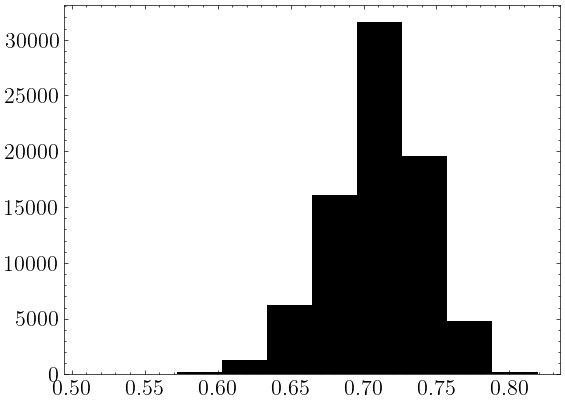

In [66]:
plt.hist(z_104_c4_PIE_logt_cool-z_104_c4_PIE_logt_rec)

In [67]:
get_quantiles(z_104_c4_PIE_logt_cool-z_104_c4_PIE_logt_rec)

0.71 -0.03 0.03


# z=1.09, PIE

## c1

In [68]:
z_109_c1_PIE_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/two_phase_CN_final.csv')

### c1L

In [69]:
z_109_c1L_PIE_logT, z_109_c1L_PIE_logt_rec, z_109_c1L_PIE_logt_cool = get_cooling_dist(z_109_c1_PIE_samples['log_hdens_p1'],
                                                                                       z_109_c1_PIE_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([13645., 24743., 12337.,  8522.,  7669.,  5911.,  4034.,  1490.,
         1259.,   390.]),
 array([3.82573675, 3.86267826, 3.89961976, 3.93656127, 3.97350277,
        4.01044428, 4.04738578, 4.08432729, 4.12126879, 4.1582103 ,
        4.1951518 ]),
 <BarContainer object of 10 artists>)

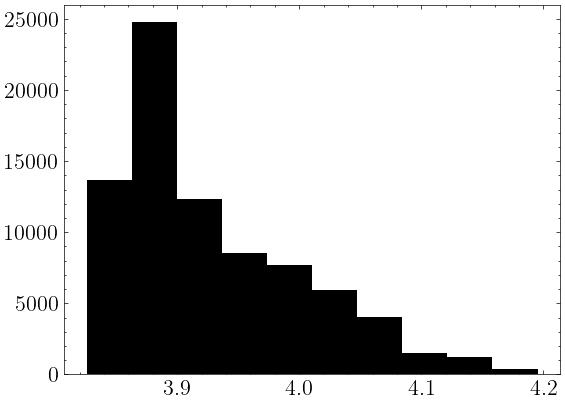

In [70]:
plt.hist(z_109_c1L_PIE_logT)

In [71]:
get_quantiles(z_109_c1L_PIE_logT), np.percentile(z_109_c1L_PIE_logT,100*cdf_3sig)

3.9 -0.04 0.11


(None, 4.18024266838885)

(array([ 4043.,  7743., 12073., 16285., 18090., 13652.,  5929.,  1680.,
          410.,    95.]),
 array([0.57775819, 0.6384993 , 0.6992404 , 0.75998151, 0.82072261,
        0.88146372, 0.94220482, 1.00294593, 1.06368703, 1.12442814,
        1.18516924]),
 <BarContainer object of 10 artists>)

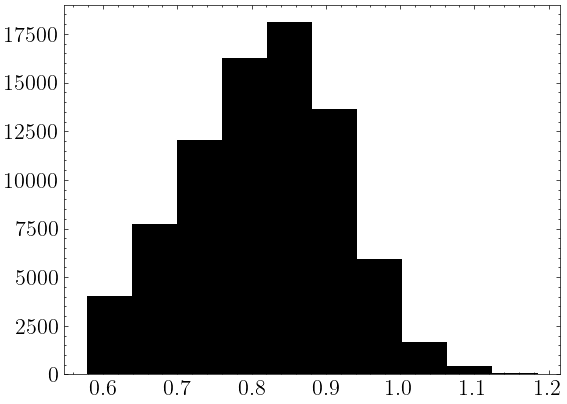

In [72]:
plt.hist(z_109_c1L_PIE_logt_rec)

In [73]:
get_quantiles(z_109_c1L_PIE_logt_rec)

0.82 -0.12 0.1


(array([  216.,  1229., 14946., 19616., 14245., 11591.,  8884.,  6287.,
         1998.,   988.]),
 array([0.11838704, 0.17088874, 0.22339044, 0.27589213, 0.32839383,
        0.38089553, 0.43339723, 0.48589893, 0.53840063, 0.59090232,
        0.64340402]),
 <BarContainer object of 10 artists>)

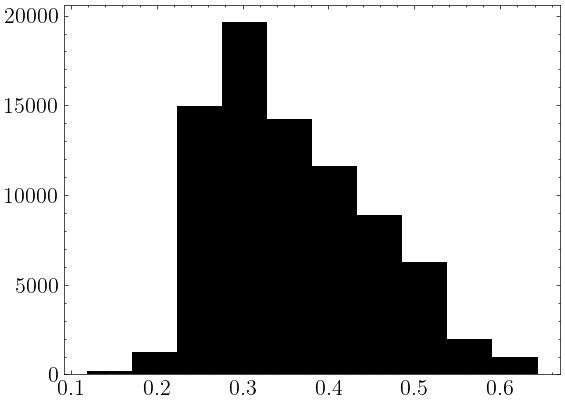

In [74]:
plt.hist(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec)

In [75]:
get_quantiles(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec)

0.34 -0.07 0.12


### c1H

In [76]:
z_109_c1H_PIE_logT, z_109_c1H_PIE_logt_rec, z_109_c1H_PIE_logt_cool = get_cooling_dist(z_109_c1_PIE_samples['log_hdens_p2'],
                                                                                       z_109_c1_PIE_samples['log_metals_p2'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([  380.,  3105., 11306., 16995., 43671.,  1673.,  1380.,   966.,
          359.,   165.]),
 array([3.71134958, 3.77592929, 3.840509  , 3.90508871, 3.96966843,
        4.03424814, 4.09882785, 4.16340756, 4.22798728, 4.29256699,
        4.3571467 ]),
 <BarContainer object of 10 artists>)

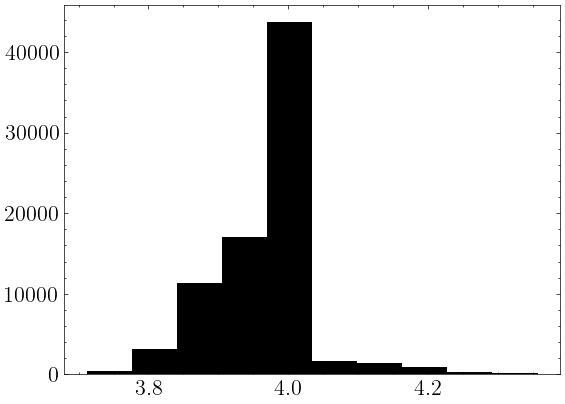

In [77]:
plt.hist(z_109_c1H_PIE_logT)

In [78]:
get_quantiles(z_109_c1H_PIE_logT), np.percentile(z_109_c1H_PIE_logT,100*cdf_3sig)

3.99 -0.1 0.01


(None, 4.3079548320530385)

(array([2.1590e+03, 2.7085e+04, 3.9992e+04, 9.4880e+03, 8.8500e+02,
        9.3000e+01, 1.1200e+02, 4.3000e+01, 2.7000e+01, 1.1600e+02]),
 array([1.12099007, 1.25816671, 1.39534335, 1.53251999, 1.66969664,
        1.80687328, 1.94404992, 2.08122656, 2.2184032 , 2.35557984,
        2.49275649]),
 <BarContainer object of 10 artists>)

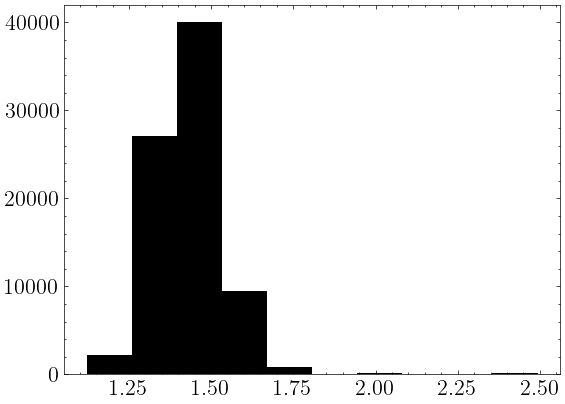

In [79]:
plt.hist(z_109_c1H_PIE_logt_rec)

In [80]:
get_quantiles(z_109_c1H_PIE_logt_rec)

1.42 -0.08 0.1


(array([ 8382., 16800., 25560., 14368.,  6431.,  3851.,  2028.,  1447.,
          889.,   244.]),
 array([-0.46506102, -0.348054  , -0.23104699, -0.11403998,  0.00296704,
         0.11997405,  0.23698107,  0.35398808,  0.4709951 ,  0.58800211,
         0.70500913]),
 <BarContainer object of 10 artists>)

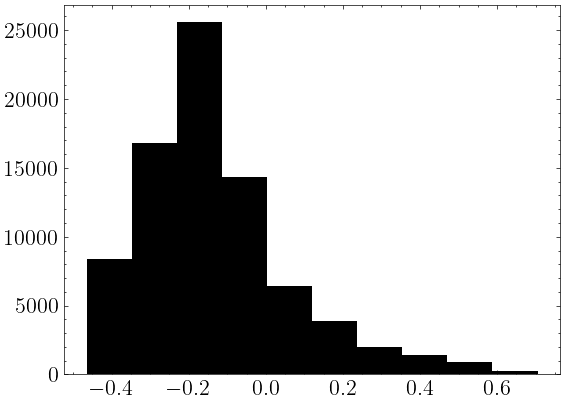

In [81]:
plt.hist(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

In [82]:
get_quantiles(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

-0.17 -0.14 0.2


# z=1.16, PIE

## c1

In [83]:
z_116_c1_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/one_phase_c1.csv')

In [84]:
z_116_c1_PIE_logT, z_116_c1_PIE_logt_rec, z_116_c1_PIE_logt_cool = get_cooling_dist(z_116_c1_PIE_samples['log_hdens'],
                                                                                    z_116_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   38.,   273.,  2151.,  8673., 18859., 23816., 17177.,  7210.,
         1675.,   128.]),
 array([4.40822187, 4.41447999, 4.42073812, 4.42699624, 4.43325437,
        4.43951249, 4.44577062, 4.45202875, 4.45828687, 4.464545  ,
        4.47080312]),
 <BarContainer object of 10 artists>)

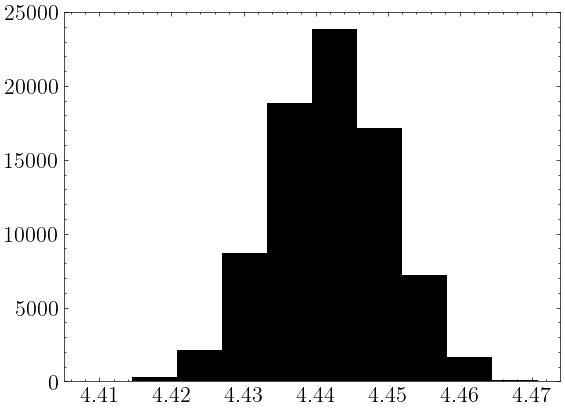

In [85]:
plt.hist(z_116_c1_PIE_logT)

In [86]:
get_quantiles(z_116_c1_PIE_logT)

4.44 -0.01 0.01


(array([   63.,   520.,  2940., 10394., 19483., 23114., 15680.,  6271.,
         1407.,   128.]),
 array([1.12728242, 1.15633445, 1.18538648, 1.2144385 , 1.24349053,
        1.27254256, 1.30159458, 1.33064661, 1.35969864, 1.38875066,
        1.41780269]),
 <BarContainer object of 10 artists>)

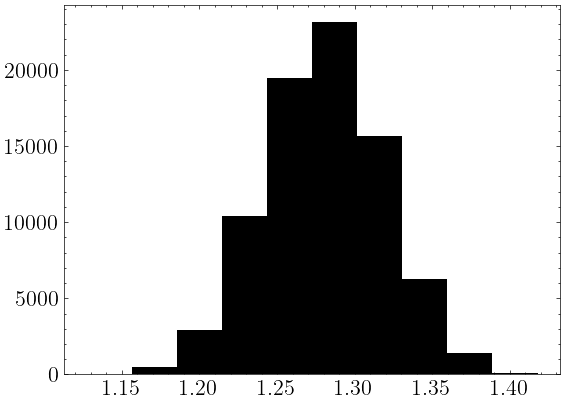

In [87]:
plt.hist(z_116_c1_PIE_logt_rec)

In [88]:
get_quantiles(z_116_c1_PIE_logt_rec)

1.28 -0.04 0.04


(array([   33.,   292.,  2450., 11009., 22785., 24323., 13879.,  4393.,
          755.,    81.]),
 array([0.88239322, 0.88624873, 0.89010423, 0.89395973, 0.89781524,
        0.90167074, 0.90552624, 0.90938175, 0.91323725, 0.91709275,
        0.92094825]),
 <BarContainer object of 10 artists>)

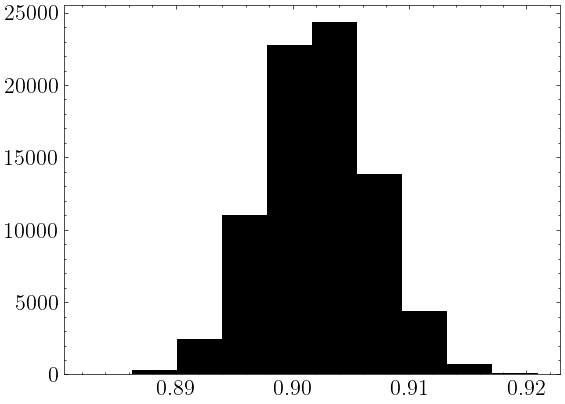

In [89]:
plt.hist(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

In [90]:
get_quantiles(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

0.9 -0.0 0.0


In [91]:
np.median(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

0.9021636563439628

In [92]:
np.median(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)-np.percentile(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec,100*(1-cdf_1sig))

0.004620103946597953

In [93]:
np.percentile(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec,100*cdf_1sig)

0.9069324508789509

## c2

In [94]:
z_116_c2_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/one_phase_c2.csv')

In [95]:
z_116_c2_PIE_logT, z_116_c2_PIE_logt_rec, z_116_c2_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens'],
                                                                                    z_116_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   73.,   227.,  1276.,  5459., 14353., 22252., 22635., 11253.,
         2253.,   219.]),
 array([4.41517201, 4.44321742, 4.47126283, 4.49930824, 4.52735364,
        4.55539905, 4.58344446, 4.61148986, 4.63953527, 4.66758068,
        4.69562609]),
 <BarContainer object of 10 artists>)

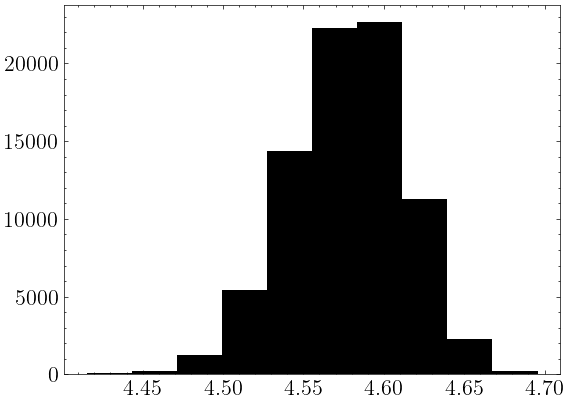

In [96]:
plt.hist(z_116_c2_PIE_logT)

In [97]:
get_quantiles(z_116_c2_PIE_logT)

4.58 -0.04 0.03


(array([1.3100e+02, 9.8900e+02, 6.0520e+03, 1.6431e+04, 2.3750e+04,
        2.0644e+04, 9.1320e+03, 2.4670e+03, 3.8600e+02, 1.8000e+01]),
 array([1.61240056, 1.72134486, 1.83028915, 1.93923344, 2.04817774,
        2.15712203, 2.26606632, 2.37501062, 2.48395491, 2.5928992 ,
        2.7018435 ]),
 <BarContainer object of 10 artists>)

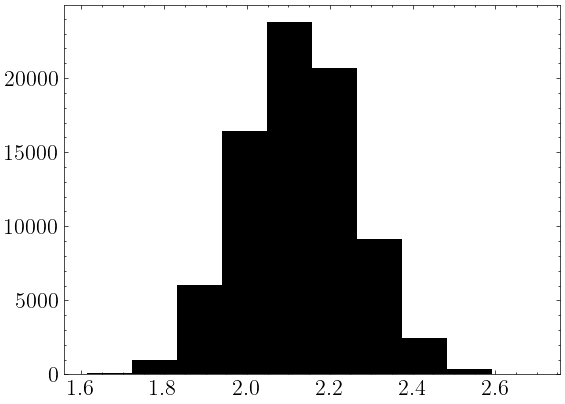

In [98]:
plt.hist(z_116_c2_PIE_logt_rec)

In [99]:
get_quantiles(z_116_c2_PIE_logt_rec)

2.12 -0.14 0.14


(array([   75.,   218.,  1061.,  4681., 12593., 21707., 22768., 13976.,
         2670.,   251.]),
 array([0.83130778, 0.85865068, 0.88599357, 0.91333647, 0.94067936,
        0.96802226, 0.99536516, 1.02270805, 1.05005095, 1.07739384,
        1.10473674]),
 <BarContainer object of 10 artists>)

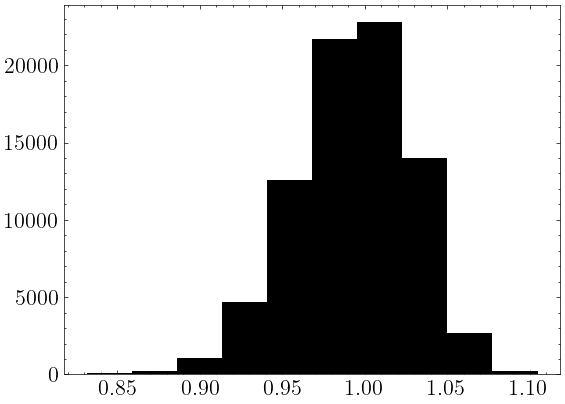

In [100]:
plt.hist(z_116_c2_PIE_logt_cool-z_116_c2_PIE_logt_rec)

In [101]:
get_quantiles(z_116_c2_PIE_logt_cool-z_116_c2_PIE_logt_rec)

0.99 -0.04 0.03


# z=1.22, PIE

## c1

In [102]:
z_122_c1_PIE_samples = pd.read_csv(loaddir+'z=1.22540771/cloudy_fits/one_phase_c1.csv')

In [103]:
z_122_c1_PIE_logT, z_122_c1_PIE_logt_rec, z_122_c1_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens'],
                                                                                    z_122_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   59.,   533.,  2749.,  8603., 17723., 24010., 18925.,  6302.,
         1009.,    87.]),
 array([4.43496533, 4.44634651, 4.45772769, 4.46910887, 4.48049004,
        4.49187122, 4.5032524 , 4.51463357, 4.52601475, 4.53739593,
        4.5487771 ]),
 <BarContainer object of 10 artists>)

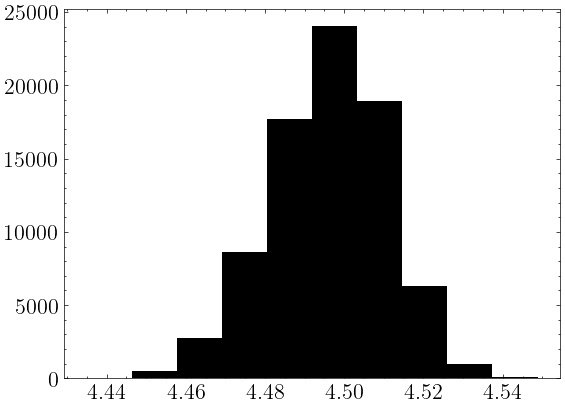

In [104]:
plt.hist(z_122_c1_PIE_logT)

In [105]:
get_quantiles(z_122_c1_PIE_logT)

4.5 -0.02 0.01


(array([   47.,   674.,  3734., 11967., 21575., 23978., 12971.,  4207.,
          731.,   116.]),
 array([2.16763396, 2.20854689, 2.24945982, 2.29037275, 2.33128568,
        2.37219861, 2.41311153, 2.45402446, 2.49493739, 2.53585032,
        2.57676325]),
 <BarContainer object of 10 artists>)

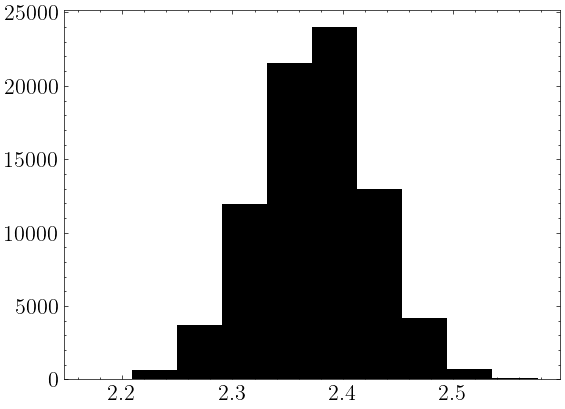

In [106]:
plt.hist(z_122_c1_PIE_logt_rec)

In [107]:
get_quantiles(z_122_c1_PIE_logt_rec)

2.38 -0.05 0.05


(array([   30.,   284.,  1377.,  4753., 10962., 20409., 26791., 13546.,
         1771.,    77.]),
 array([0.75484013, 0.76682442, 0.77880872, 0.79079302, 0.80277732,
        0.81476161, 0.82674591, 0.83873021, 0.8507145 , 0.8626988 ,
        0.8746831 ]),
 <BarContainer object of 10 artists>)

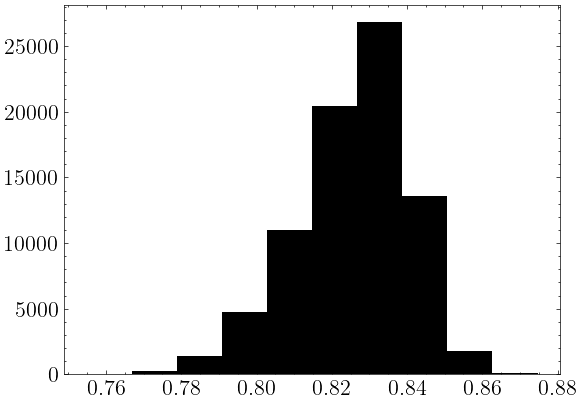

In [108]:
plt.hist(z_122_c1_PIE_logt_cool-z_122_c1_PIE_logt_rec)

In [109]:
get_quantiles(z_122_c1_PIE_logt_cool-z_122_c1_PIE_logt_rec)

0.83 -0.02 0.01


# z=1.26, PIE

## c1

In [141]:
z_126_c1_PIE_samples = pd.read_csv(loaddir+'z=1.25937492/cloudy_fits/one_phase_c1.csv')

In [142]:
z_126_c1_PIE_logT, z_126_c1_PIE_logt_rec, z_126_c1_PIE_logt_cool = get_cooling_dist(z_126_c1_PIE_samples['log_hdens'],
                                                                                    z_126_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([4.1070e+03, 7.7360e+03, 8.8040e+03, 9.8440e+03, 1.0331e+04,
        3.8743e+04, 3.0700e+02, 1.1100e+02, 1.5000e+01, 2.0000e+00]),
 array([3.65043412, 3.71525597, 3.78007781, 3.84489965, 3.90972149,
        3.97454333, 4.03936518, 4.10418702, 4.16900886, 4.2338307 ,
        4.29865254]),
 <BarContainer object of 10 artists>)

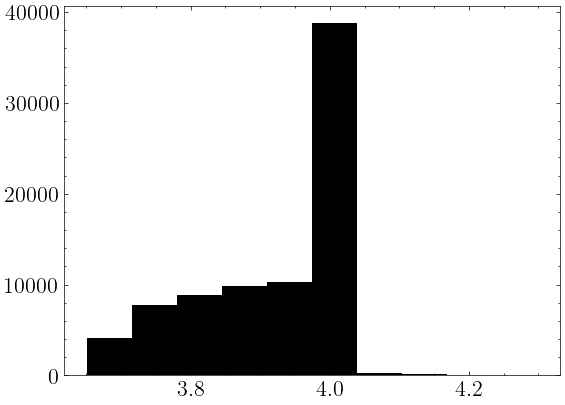

In [143]:
plt.hist(z_126_c1_PIE_logT)

In [144]:
get_quantiles(z_126_c1_PIE_logT), np.percentile(z_126_c1_PIE_logT, 100*cdf_3sig)

3.97 -0.18 0.03


(None, 4.114734701595512)

(array([1.9580e+03, 1.0531e+04, 1.9255e+04, 3.9339e+04, 6.2740e+03,
        1.9100e+03, 6.0400e+02, 1.1300e+02, 1.4000e+01, 2.0000e+00]),
 array([0.73011012, 0.83132821, 0.9325463 , 1.03376438, 1.13498247,
        1.23620056, 1.33741865, 1.43863674, 1.53985483, 1.64107292,
        1.74229101]),
 <BarContainer object of 10 artists>)

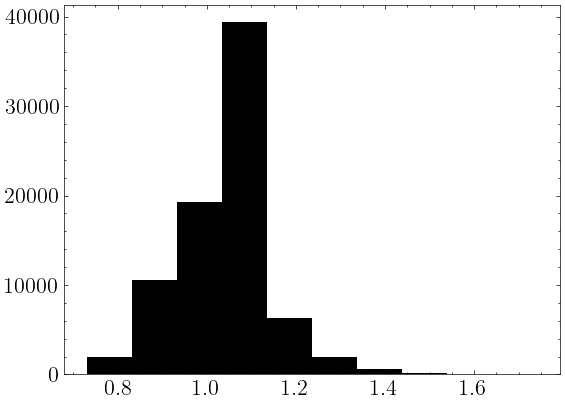

In [145]:
plt.hist(z_126_c1_PIE_logt_rec)

In [146]:
get_quantiles(z_126_c1_PIE_logt_rec)

1.05 -0.11 0.06


(array([1.5960e+03, 7.2730e+03, 1.5405e+04, 3.3784e+04, 1.5706e+04,
        3.9830e+03, 1.5770e+03, 5.3900e+02, 1.2900e+02, 8.0000e+00]),
 array([-0.44946184, -0.34100825, -0.23255466, -0.12410106, -0.01564747,
         0.09280612,  0.20125971,  0.30971331,  0.4181669 ,  0.52662049,
         0.63507408]),
 <BarContainer object of 10 artists>)

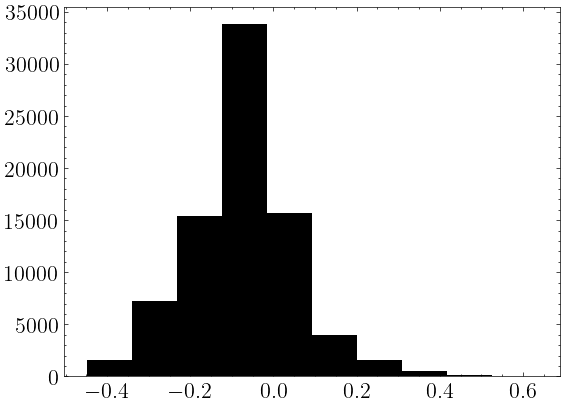

In [147]:
plt.hist(z_126_c1_PIE_logt_cool-z_126_c1_PIE_logt_rec)

In [148]:
get_quantiles(z_126_c1_PIE_logt_cool-z_126_c1_PIE_logt_rec)

-0.07 -0.13 0.1


# z=1.27, PIE

## c1

In [72]:
z_127_c1_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/two_phase_CN_c1.csv')

### c1L

In [73]:
z_127_c1L_PIE_logT, z_127_c1L_PIE_logt_rec, z_127_c1L_PIE_logt_cool = get_cooling_dist(z_127_c1_PIE_samples['log_hdens_p1'],
                                                                                       z_127_c1_PIE_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([ 7562., 15132., 13195., 10686., 14435.,  5704.,  5832.,  4892.,
         2268.,   294.]),
 array([3.75748112, 3.81185844, 3.86623577, 3.92061309, 3.97499041,
        4.02936773, 4.08374505, 4.13812237, 4.19249969, 4.24687701,
        4.30125434]),
 <BarContainer object of 10 artists>)

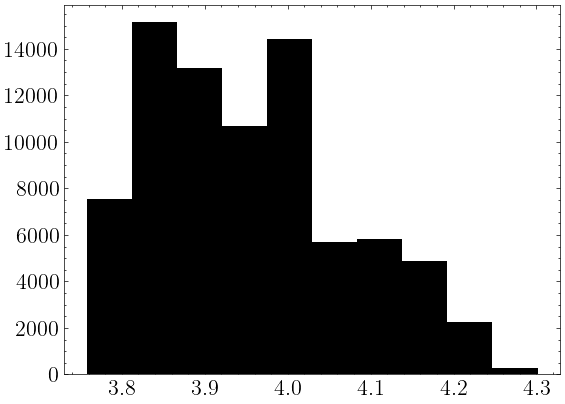

In [74]:
plt.hist(z_127_c1L_PIE_logT)

In [75]:
get_quantiles(z_127_c1L_PIE_logT)

3.94 -0.11 0.15


(array([  398.,  4114., 15363., 21636., 14404.,  9421.,  6399.,  4656.,
         3230.,   379.]),
 array([-0.61781723, -0.39382302, -0.1698288 ,  0.05416541,  0.27815963,
         0.50215384,  0.72614805,  0.95014227,  1.17413648,  1.3981307 ,
         1.62212491]),
 <BarContainer object of 10 artists>)

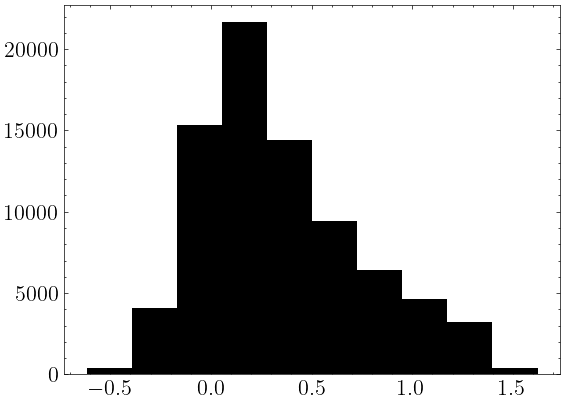

In [76]:
plt.hist(z_127_c1L_PIE_logt_rec)

In [77]:
get_quantiles(z_127_c1L_PIE_logt_rec)

0.26 -0.29 0.52


(array([  574.,  1019.,  2042.,  3195.,  4876., 10817., 15606., 20851.,
        19554.,  1466.]),
 array([-0.43196584, -0.31192597, -0.1918861 , -0.07184623,  0.04819365,
         0.16823352,  0.28827339,  0.40831326,  0.52835313,  0.64839301,
         0.76843288]),
 <BarContainer object of 10 artists>)

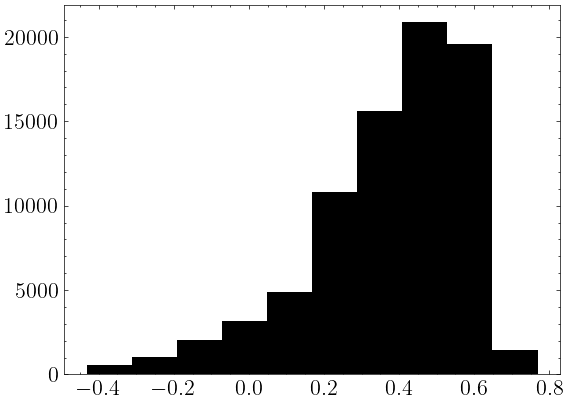

In [78]:
plt.hist(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec)

In [79]:
get_quantiles(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec)

0.42 -0.24 0.15


### c1H

In [80]:
z_127_c1H_PIE_logT, z_127_c1H_PIE_logt_rec, z_127_c1H_PIE_logt_cool = get_cooling_dist(z_127_c1_PIE_samples['log_hdens_p2'],
                                                                                       z_127_c1_PIE_samples['log_metals_p2'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([   31.,   286.,  1649.,  5581., 13256., 23321., 23675., 10432.,
         1585.,   184.]),
 array([3.99331289, 4.0366216 , 4.07993031, 4.12323902, 4.16654774,
        4.20985645, 4.25316516, 4.29647387, 4.33978258, 4.3830913 ,
        4.42640001]),
 <BarContainer object of 10 artists>)

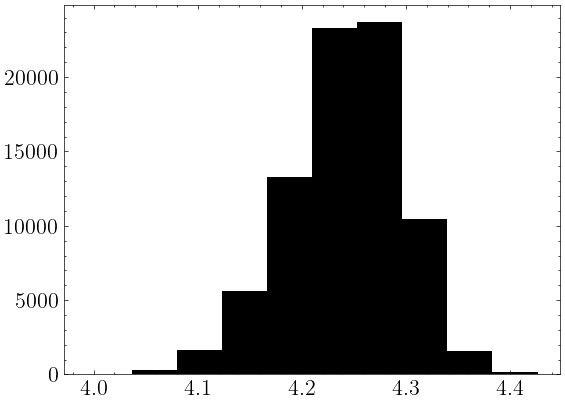

In [81]:
plt.hist(z_127_c1H_PIE_logT)

In [82]:
get_quantiles(z_127_c1H_PIE_logT)

4.25 -0.06 0.05


(array([5.0000e+00, 1.6200e+02, 1.9780e+03, 9.9730e+03, 2.1925e+04,
        2.4216e+04, 1.4854e+04, 4.9850e+03, 1.5240e+03, 3.7800e+02]),
 array([1.78259354, 1.85260039, 1.92260724, 1.99261409, 2.06262094,
        2.13262779, 2.20263465, 2.2726415 , 2.34264835, 2.4126552 ,
        2.48266205]),
 <BarContainer object of 10 artists>)

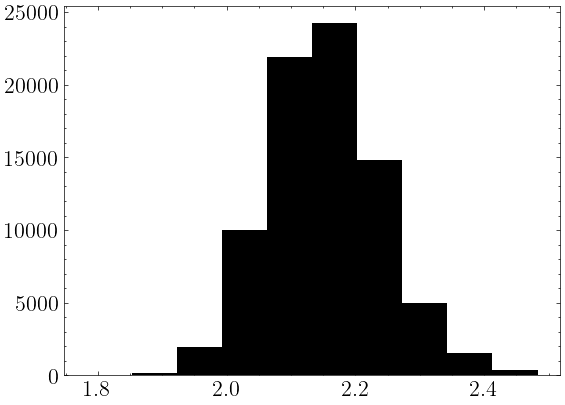

In [83]:
plt.hist(z_127_c1H_PIE_logt_rec)

In [84]:
get_quantiles(z_127_c1H_PIE_logt_rec)

2.15 -0.08 0.09


(array([ 3362.,  7178., 10105., 12935., 14093., 15464., 10498.,  5259.,
         1011.,    95.]),
 array([-0.39656779, -0.29702464, -0.19748148, -0.09793832,  0.00160483,
         0.10114799,  0.20069115,  0.3002343 ,  0.39977746,  0.49932062,
         0.59886378]),
 <BarContainer object of 10 artists>)

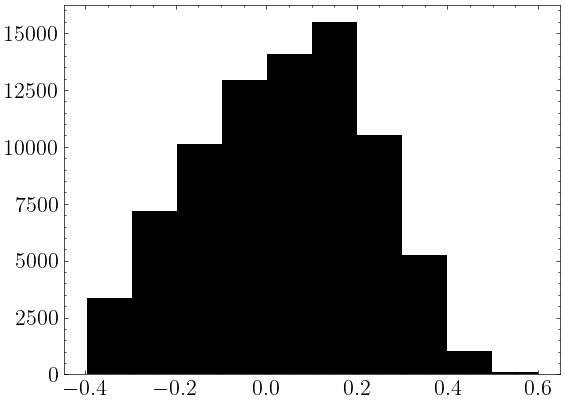

In [85]:
plt.hist(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

In [86]:
get_quantiles(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

0.05 -0.22 0.19


## c2

In [133]:
z_127_c2_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/one_phase_c2.csv')

In [134]:
z_127_c2_PIE_logT, z_127_c2_PIE_logt_rec, z_127_c2_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens'],
                                                                                    z_127_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([2.2000e+01, 1.1100e+02, 7.4400e+02, 3.9920e+03, 1.3140e+04,
        2.7763e+04, 2.3766e+04, 9.0390e+03, 1.3660e+03, 5.7000e+01]),
 array([4.24764318, 4.27135369, 4.29506421, 4.31877472, 4.34248523,
        4.36619575, 4.38990626, 4.41361678, 4.43732729, 4.4610378 ,
        4.48474832]),
 <BarContainer object of 10 artists>)

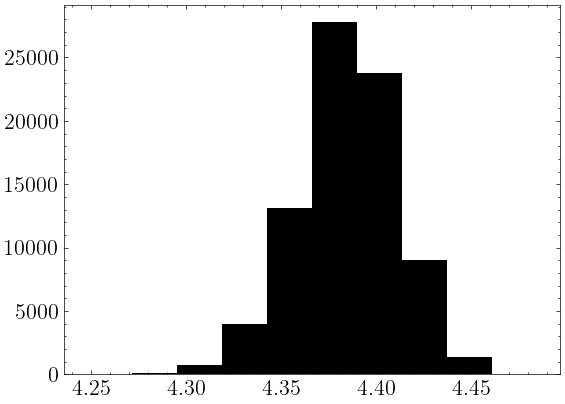

In [135]:
plt.hist(z_127_c2_PIE_logT)

In [136]:
get_quantiles(z_127_c2_PIE_logT)

4.39 -0.03 0.03


(array([2.2000e+01, 9.7000e+01, 1.1990e+03, 7.6020e+03, 2.1150e+04,
        2.7770e+04, 1.6671e+04, 4.8720e+03, 5.8700e+02, 3.0000e+01]),
 array([1.73721117, 1.80907157, 1.88093197, 1.95279238, 2.02465278,
        2.09651318, 2.16837358, 2.24023399, 2.31209439, 2.38395479,
        2.45581519]),
 <BarContainer object of 10 artists>)

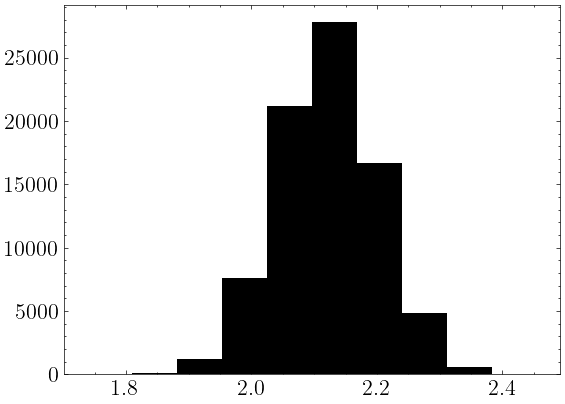

In [137]:
plt.hist(z_127_c2_PIE_logt_rec)

In [138]:
get_quantiles(z_127_c2_PIE_logt_rec)

2.12 -0.08 0.08


(array([1.1000e+01, 1.6300e+02, 7.0200e+02, 3.8060e+03, 1.3247e+04,
        2.5479e+04, 2.3793e+04, 1.0515e+04, 2.1580e+03, 1.2600e+02]),
 array([0.51172962, 0.53905703, 0.56638444, 0.59371185, 0.62103927,
        0.64836668, 0.67569409, 0.70302151, 0.73034892, 0.75767633,
        0.78500375]),
 <BarContainer object of 10 artists>)

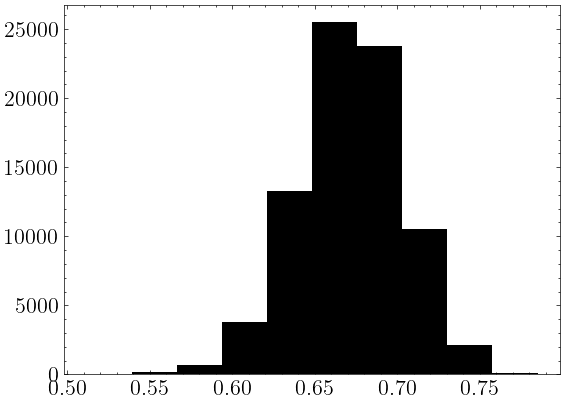

In [139]:
plt.hist(z_127_c2_PIE_logt_cool-z_127_c2_PIE_logt_rec)

In [140]:
get_quantiles(z_127_c2_PIE_logt_cool-z_127_c2_PIE_logt_rec)

0.67 -0.03 0.03


# Functions for TDP cooling

In [152]:
# TDP model grid points
log_metals_arr_TDP = [-2.6,-2.4,-2.2,-2.0,-1.8,-1.6,-1.4,-1.2,-1.0 ,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0]
log_hdens_arr_TDP = [-4.8,-4.6,-4.4,-4.0,-3.8,-3.6,-3.4,-3.2,-3.0,-2.8,-2.6,-2.4,-2.2,-2.0,-1.8,-1.6]
logT_arr_TDP = np.arange(4.00, 6.01, 0.01)

Interpolate temperatures and cooling times

In [153]:
pkl_file = open(rootdir+'cloudy_grids/TDP_cool.pkl', 'rb')
log_cool_TDP_samples = pickle.load(pkl_file)
pkl_file.close()

In [154]:
log_cool_TDP_interp = RegularGridInterpolator((log_metals_arr_TDP, log_hdens_arr_TDP, logT_arr_TDP), log_cool_TDP_samples)

Functions to get TDP cooling times

In [155]:
def compute_tcool_TDP(log_metals, log_hdens, logT, log_cool_TDP_interp):
    
    Ctot = 10**log_cool_TDP_interp((log_metals, log_hdens, logT))
    
    # Equation from Gnat and Sternberg 2007
    t_cool = 4.34*1.5*(1.38*1e-16*10**logT)/(Ctot/10**log_hdens)
    
    return t_cool*t_Myr_sec

In [156]:
def get_cooling_dist_TDP(log_metals_samples, log_hdens_samples, logT_samples, logq_rec_interp, log_cool_TDP_interp):
    
    # Distribution of recombination times
    logt_rec_samples = logt_rec(log_hdens_samples, logT_samples, logq_rec_interp)
    
    # Distribution of cooling times
    logt_cool_samples = np.log10(compute_tcool_TDP(log_metals_samples, log_hdens_samples, logT_samples, log_cool_TDP_interp))
    
    return np.array(logt_rec_samples), np.array(logt_cool_samples)

# z=0.67

## c1

In [157]:
z_067_c1_TDP_samples = pd.read_csv(loaddir+'z=0.67545705/cloudy_fits/TDP_3.csv')

### c1L

In [158]:
z_067_c1L_TDP_logt_rec, z_067_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_067_c1_TDP_samples['log_metals_p1'], 
                                                                   z_067_c1_TDP_samples['log_hdens_p1'],
                                                                   z_067_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([  233.,   596.,  2033.,  4992.,  8626., 11950., 19349., 23706.,
         8064.,   451.]),
 array([-0.40073044, -0.18844339,  0.02384366,  0.23613071,  0.44841776,
         0.66070481,  0.87299186,  1.08527891,  1.29756596,  1.509853  ,
         1.72214005]),
 <BarContainer object of 10 artists>)

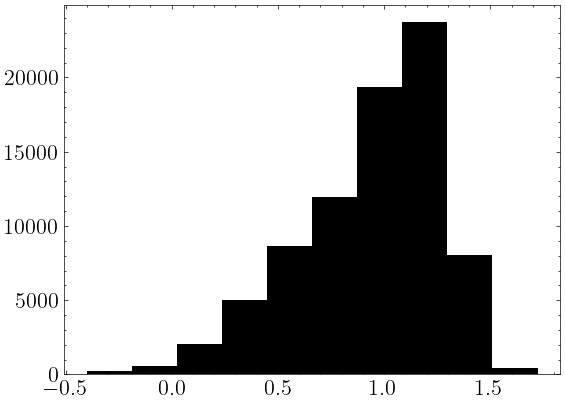

In [159]:
plt.hist(z_067_c1L_TDP_logt_rec)

In [160]:
get_quantiles(z_067_c1L_TDP_logt_rec)

1.01 -0.44 0.23


(array([9.6640e+03, 5.1838e+04, 1.7951e+04, 3.6900e+02, 7.8000e+01,
        3.3000e+01, 2.8000e+01, 3.8000e+01, 0.0000e+00, 1.0000e+00]),
 array([0.25529485, 0.52553135, 0.79576786, 1.06600436, 1.33624087,
        1.60647738, 1.87671388, 2.14695039, 2.41718689, 2.6874234 ,
        2.95765991]),
 <BarContainer object of 10 artists>)

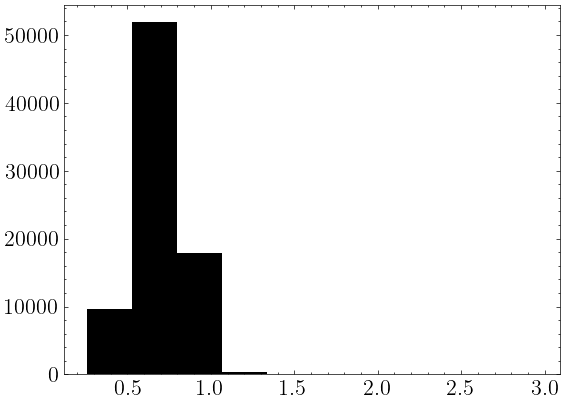

In [161]:
plt.hist(z_067_c1L_TDP_logt_cool-z_067_c1L_TDP_logt_rec)

In [162]:
get_quantiles(z_067_c1L_TDP_logt_cool-z_067_c1L_PIE_logt_rec)

0.9 -0.57 0.46


### c1H

In [163]:
z_067_c1H_TDP_logt_rec, z_067_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_067_c1_TDP_samples['log_metals_p2'], 
                                                                   z_067_c1_TDP_samples['log_hdens_p2'],
                                                                   z_067_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([1.7100e+02, 7.7000e+02, 1.5050e+03, 3.8960e+03, 9.6570e+03,
        1.7084e+04, 2.8406e+04, 1.7417e+04, 1.0810e+03, 1.3000e+01]),
 array([1.75976289, 1.86707555, 1.97438821, 2.08170087, 2.18901353,
        2.29632619, 2.40363886, 2.51095152, 2.61826418, 2.72557684,
        2.8328895 ]),
 <BarContainer object of 10 artists>)

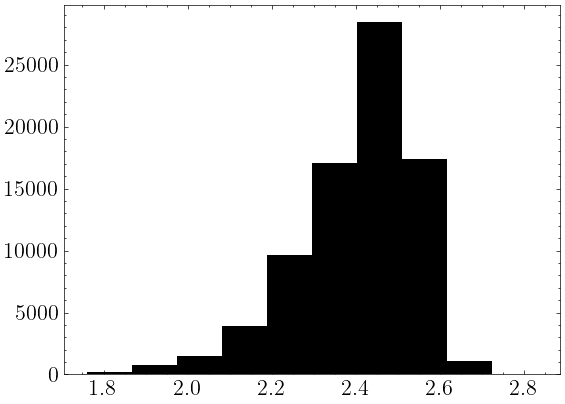

In [164]:
plt.hist(z_067_c1H_TDP_logt_rec)

In [165]:
get_quantiles(z_067_c1H_TDP_logt_rec)

2.43 -0.16 0.1


(array([  479.,  1612.,  2644.,  3592.,  6503., 11710., 23289., 23859.,
         5708.,   604.]),
 array([-0.79916646, -0.66226482, -0.52536319, -0.38846156, -0.25155993,
        -0.1146583 ,  0.02224334,  0.15914497,  0.2960466 ,  0.43294823,
         0.56984987]),
 <BarContainer object of 10 artists>)

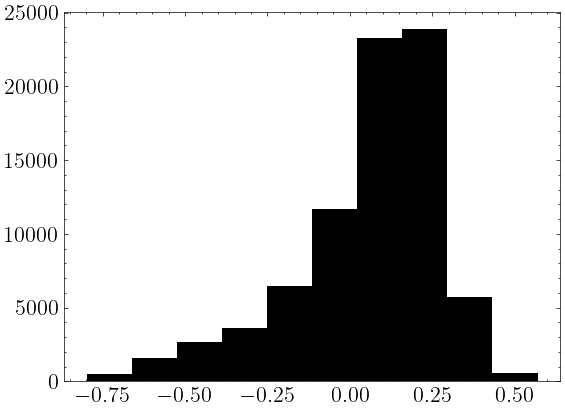

In [166]:
plt.hist(z_067_c1H_TDP_logt_cool-z_067_c1H_TDP_logt_rec)

In [167]:
get_quantiles(z_067_c1H_TDP_logt_cool-z_067_c1H_PIE_logt_rec)

0.57 -0.34 0.2


# z=1.09

## c1

In [168]:
z_109_c1_TDP_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/TDP_3.csv')

### c1L

In [169]:
z_109_c1L_TDP_logt_rec, z_109_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_TDP_samples['log_metals_p1'], 
                                                                   z_109_c1_TDP_samples['log_hdens_p1'],
                                                                   z_109_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([  260.,   998.,  3501.,  9108., 13711., 18125., 18402., 11773.,
         3547.,   575.]),
 array([0.69322237, 0.79131356, 0.88940474, 0.98749593, 1.08558711,
        1.1836783 , 1.28176949, 1.37986067, 1.47795186, 1.57604304,
        1.67413423]),
 <BarContainer object of 10 artists>)

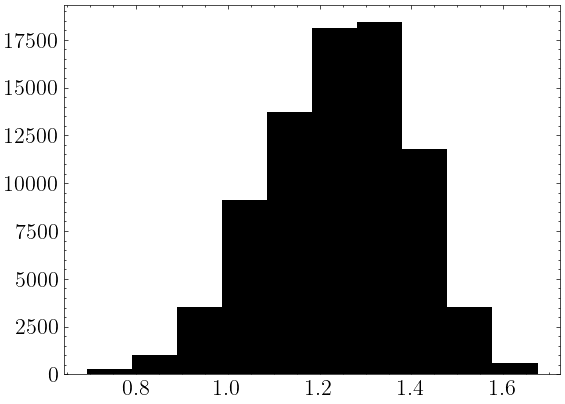

In [170]:
plt.hist(z_109_c1L_TDP_logt_rec)

In [171]:
get_quantiles(z_109_c1L_TDP_logt_rec)

1.25 -0.18 0.15


(array([2.6000e+01, 4.9700e+02, 3.7480e+03, 1.4723e+04, 2.6617e+04,
        2.4405e+04, 9.6150e+03, 3.1300e+02, 3.5000e+01, 2.1000e+01]),
 array([0.10410012, 0.24819828, 0.39229644, 0.5363946 , 0.68049276,
        0.82459092, 0.96868908, 1.11278724, 1.25688539, 1.40098355,
        1.54508171]),
 <BarContainer object of 10 artists>)

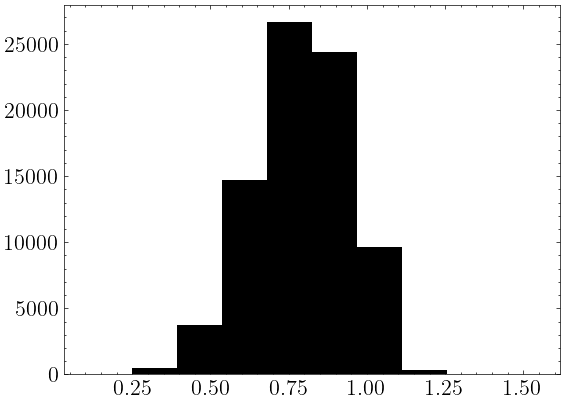

In [172]:
plt.hist(z_109_c1L_TDP_logt_cool-z_109_c1L_TDP_logt_rec)

In [173]:
get_quantiles(z_109_c1L_TDP_logt_cool-z_109_c1L_PIE_logt_rec)

1.23 -0.28 0.26


### c1H

In [174]:
z_109_c1H_TDP_logt_rec, z_109_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_TDP_samples['log_metals_p2'], 
                                                                   z_109_c1_TDP_samples['log_hdens_p2'],
                                                                   z_109_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([1.4200e+02, 4.7200e+02, 2.2890e+03, 7.0660e+03, 1.4685e+04,
        2.3133e+04, 2.5545e+04, 6.1570e+03, 4.9200e+02, 1.9000e+01]),
 array([1.4533393 , 1.54113434, 1.62892939, 1.71672444, 1.80451949,
        1.89231453, 1.98010958, 2.06790463, 2.15569967, 2.24349472,
        2.33128977]),
 <BarContainer object of 10 artists>)

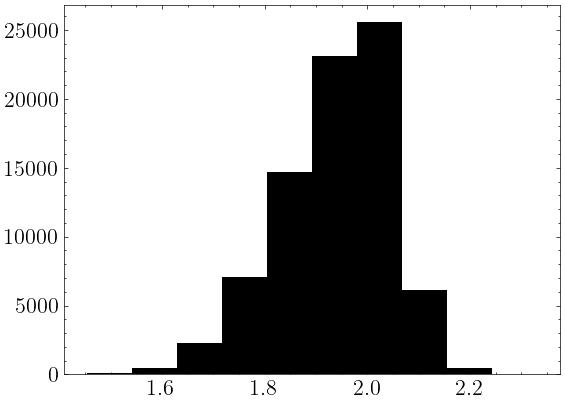

In [175]:
plt.hist(z_109_c1H_TDP_logt_rec)

In [176]:
get_quantiles(z_109_c1H_TDP_logt_rec)

1.95 -0.13 0.09


(array([  556.,  3550.,  7634., 10860., 13822., 15390., 12552.,  9450.,
         5440.,   746.]),
 array([-0.8169372 , -0.68990535, -0.56287349, -0.43584164, -0.30880978,
        -0.18177793, -0.05474607,  0.07228578,  0.19931764,  0.32634949,
         0.45338135]),
 <BarContainer object of 10 artists>)

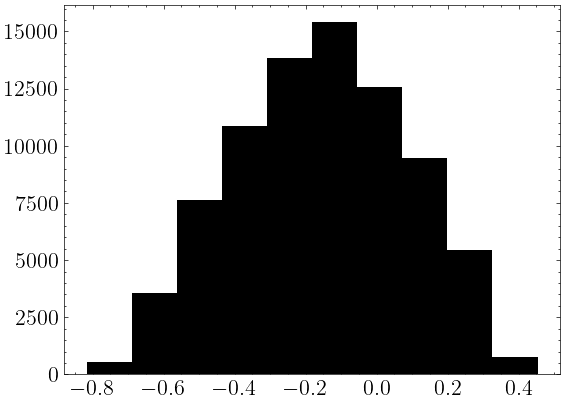

In [177]:
plt.hist(z_109_c1H_TDP_logt_cool-z_109_c1H_TDP_logt_rec)

In [178]:
get_quantiles(z_109_c1H_TDP_logt_cool-z_109_c1H_PIE_logt_rec)

0.36 -0.32 0.29


# z=1.26

## c1

In [179]:
z_126_c1_TDP_samples = pd.read_csv(loaddir+'z=1.25937492/cloudy_fits/TDP.csv')

In [180]:
z_126_c1_TDP_logt_rec, z_126_c1_TDP_logt_cool = get_cooling_dist_TDP(z_126_c1_TDP_samples['log_metals'], 
                                                                   z_126_c1_TDP_samples['log_hdens'],
                                                                   z_126_c1_TDP_samples['logT'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([ 1207.,  9024., 15908., 21447., 16711., 10051.,  4214.,  1131.,
          277.,    30.]),
 array([0.81369863, 0.91937521, 1.02505179, 1.13072837, 1.23640495,
        1.34208153, 1.44775811, 1.55343469, 1.65911127, 1.76478785,
        1.87046443]),
 <BarContainer object of 10 artists>)

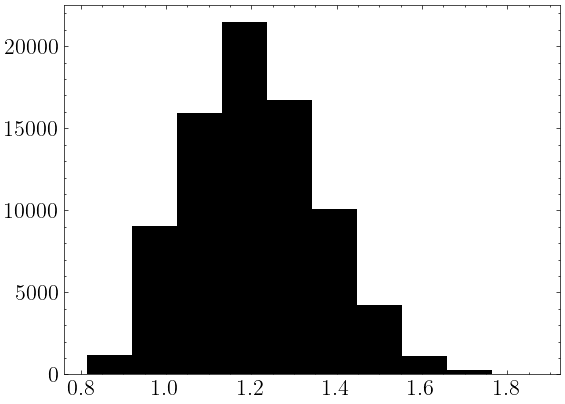

In [181]:
plt.hist(z_126_c1_TDP_logt_rec)

In [182]:
get_quantiles(z_126_c1_TDP_logt_rec)

1.2 -0.15 0.17


(array([  546.,  4805., 15004., 22020., 18317., 11178.,  5660.,  1883.,
          491.,    96.]),
 array([-0.41377925, -0.30754132, -0.20130339, -0.09506546,  0.01117247,
         0.1174104 ,  0.22364833,  0.32988626,  0.43612419,  0.54236212,
         0.64860005]),
 <BarContainer object of 10 artists>)

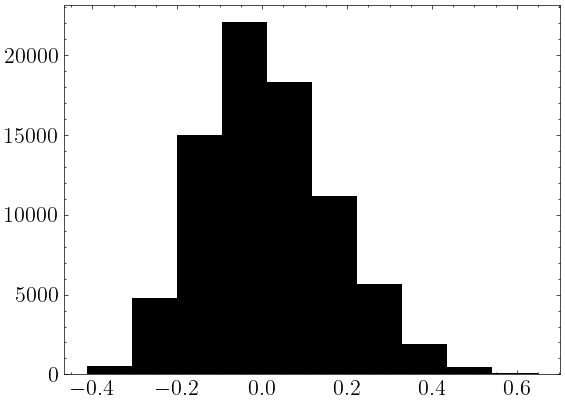

In [183]:
plt.hist(z_126_c1_TDP_logt_cool-z_126_c1_TDP_logt_rec)

In [184]:
get_quantiles(z_126_c1_TDP_logt_cool-z_126_c1_TDP_logt_rec)

-0.0 -0.14 0.17


# z=1.27

## c1

In [70]:
z_127_c1_TDP_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/TDP_3.csv')

### c1L

In [71]:
z_127_c1L_TDP_logt_rec, z_127_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_TDP_samples['log_metals_p1'], 
                                                                   z_127_c1_TDP_samples['log_hdens_p1'],
                                                                   z_127_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

NameError: name 'get_cooling_dist_TDP' is not defined

In [69]:
plt.hist(z_127_c1L_TDP_logt_rec)

NameError: name 'z_127_c1L_TDP_logt_rec' is not defined

In [188]:
get_quantiles(z_127_c1L_TDP_logt_rec)

1.38 -0.3 0.19


(array([3.9000e+02, 9.4030e+03, 6.5743e+04, 4.1940e+03, 2.2100e+02,
        1.5000e+01, 2.4000e+01, 8.0000e+00, 0.0000e+00, 2.0000e+00]),
 array([-0.30293068, -0.03535593,  0.23221882,  0.49979357,  0.76736832,
         1.03494307,  1.30251782,  1.57009257,  1.83766732,  2.10524207,
         2.37281682]),
 <BarContainer object of 10 artists>)

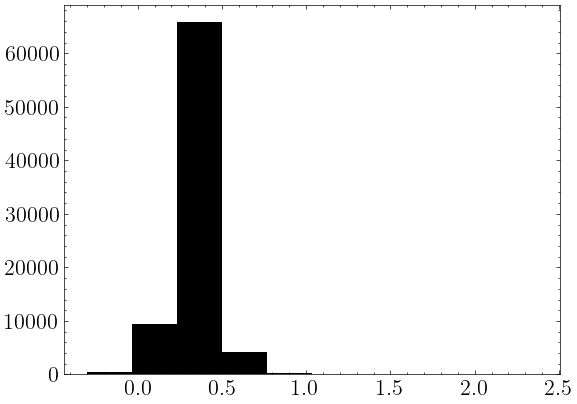

In [189]:
plt.hist(z_127_c1L_TDP_logt_cool-z_127_c1L_TDP_logt_rec)

In [190]:
get_quantiles(z_127_c1L_TDP_logt_cool-z_127_c1L_PIE_logt_rec)

0.98 -0.53 0.57


### c1H

In [191]:
z_127_c1H_TDP_logt_rec, z_127_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_TDP_samples['log_metals_p2'], 
                                                                   z_127_c1_TDP_samples['log_hdens_p2'],
                                                                   z_127_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   91.,   261.,   837.,  4074., 11204., 25157., 22453., 12393.,
         3255.,   275.]),
 array([2.1521672 , 2.24859892, 2.34503063, 2.44146234, 2.53789405,
        2.63432577, 2.73075748, 2.82718919, 2.9236209 , 3.02005262,
        3.11648433]),
 <BarContainer object of 10 artists>)

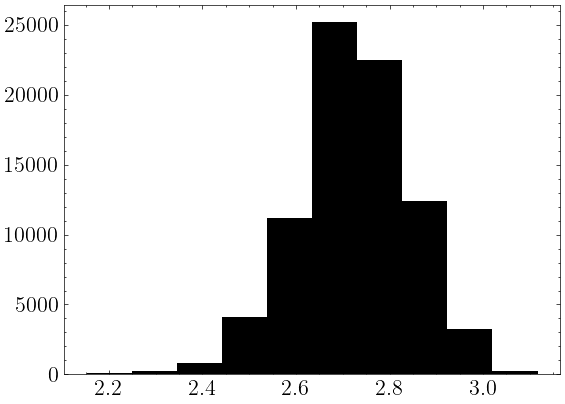

In [192]:
plt.hist(z_127_c1H_TDP_logt_rec)

In [193]:
get_quantiles(z_127_c1H_TDP_logt_rec)

2.73 -0.12 0.12


(array([ 1359.,  7840., 12976., 17136., 17164., 12426.,  7364.,  2863.,
          781.,    91.]),
 array([-0.62194789, -0.48887766, -0.35580744, -0.22273722, -0.089667  ,
         0.04340322,  0.17647344,  0.30954366,  0.44261388,  0.5756841 ,
         0.70875433]),
 <BarContainer object of 10 artists>)

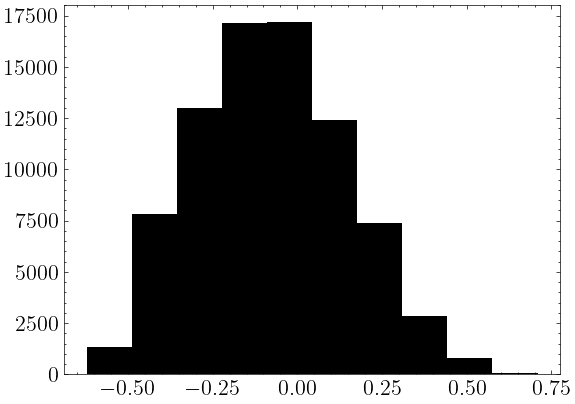

In [194]:
plt.hist(z_127_c1H_TDP_logt_cool-z_127_c1H_TDP_logt_rec)

In [195]:
get_quantiles(z_127_c1H_TDP_logt_cool-z_127_c1H_PIE_logt_rec)

0.33 -0.28 0.22
